In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

In [2]:
# Chatgpt helped here with cleaning and formatting the data
x_df = pd.read_csv("x.txt", header=None)
y_df = pd.read_csv("y.txt", header=None)
z_df = pd.read_csv("z.txt", header=None)

# assume: column 0 = time, column 1 = value
t = pd.to_datetime(x_df.iloc[:, 0])
t = (t - t.iloc[0]).dt.total_seconds().to_numpy()

x = x_df.iloc[:, 1].to_numpy()
y = y_df.iloc[:, 1].to_numpy()
z = z_df.iloc[:, 1].to_numpy()

n = min(len(t), len(x), len(y), len(z))

df = pd.DataFrame({
    "time": t[:n],
    "x": x[:n],
    "y": y[:n],
    "z": z[:n]
})

df.to_csv("output.csv", index=False);


         time         x         y         z
0       0.000  0.086914 -0.222336 -0.970139
1       0.094  0.069443 -0.139633 -1.021744
2       0.195 -0.000900 -0.152359 -0.970993
3       0.296  0.015182 -0.176544 -0.901871
4       0.397 -0.048721 -0.163681 -1.008362
...       ...       ...       ...       ...
7552  750.847  0.339233 -0.517746 -0.786026
7553  750.948  0.520538 -0.466263 -0.809845
7554  751.048  0.522659 -0.482422 -0.841171
7555  751.144  0.481857 -0.480774 -0.752167
7556  751.245  0.544235 -0.409683 -0.692795

[7557 rows x 4 columns]


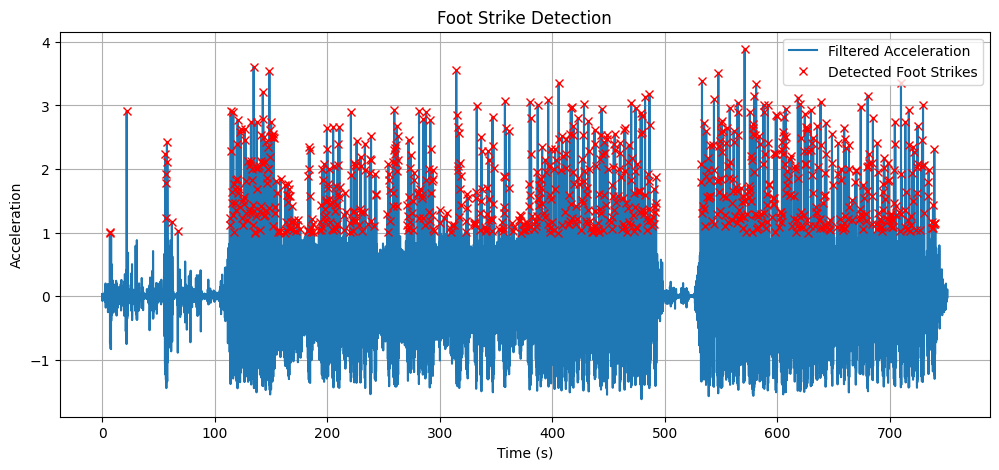

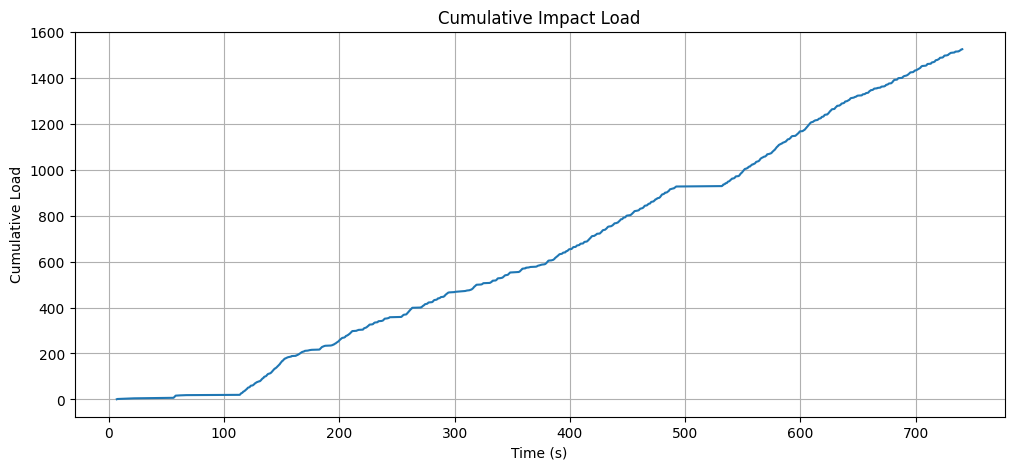

Average impact per step: 1.7398
Total cumulative load: 1524.0589885713691
Detected steps: 876
Estimated cadence: 70.0 steps/min
Mean peak acceleration: 1.74
Max peak acceleration: 3.88


In [3]:
df = pd.read_csv("output.csv")


df["time"] = t
df[["x","y","z"]] = df[["x","y","z"]].astype(float)

time = df["time"].values
ax = df["x"].values
ay = df["y"].values
az = df["z"].values
print(df)
acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

# Filtering

fs = 10  # sampling frequency (Hz)

def highpass_filter(signal, cutoff=0.5, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal)

filtered_acc = highpass_filter(acc_mag, cutoff=0.5, fs=fs)

# Foot Strike Detection

min_distance = int(0.2 * fs)

peaks, properties = find_peaks(
    filtered_acc,
    height=1,      
    distance=min_distance
)

peak_times = time[peaks]
peak_values = filtered_acc[peaks]

# Cumulative Load Calculation
cumulative_load = np.cumsum(peak_values)

# Foot strike plot

plt.figure(figsize=(12,5))
plt.plot(time, filtered_acc, label="Filtered Acceleration")
plt.plot(peak_times, peak_values, "rx", label="Detected Foot Strikes")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title("Foot Strike Detection")
plt.legend()
plt.savefig("slow_peaks", dpi=300, bbox_inches="tight")
plt.grid(True)

# Cumulative Load Plot

plt.figure(figsize=(12,5))
plt.plot(peak_times, cumulative_load)
plt.xlabel("Time (s)")
plt.ylabel("Cumulative Load")
plt.title("Cumulative Impact Load")
plt.savefig("slow_load", dpi=300, bbox_inches="tight")
plt.grid(True)

plt.show()

# Basic Data

cadence = len(peaks) / (time[-1] / 60)
total_load = cumulative_load[-1]
avg_impact_per_step = np.mean(peak_values)

# Chatgpt helped with printing these
print(f"Average impact per step: {avg_impact_per_step:.4f}")
print("Total cumulative load:", total_load)
print(f"Detected steps: {len(peaks)}")
print(f"Estimated cadence: {cadence:.1f} steps/min")
print(f"Mean peak acceleration: {np.mean(peak_values):.2f}")
print(f"Max peak acceleration: {np.max(peak_values):.2f}")
